In [113]:
import numpy as np
import pandas as pd

In [114]:
df_places = pd.read_csv("/content/places.csv", encoding='cp1251')
df_vacancies = pd.read_csv("/content/vacancies.csv", encoding='cp1251')

Напишем отдельный код для разбиения на списки станции метро и вемя до них, чтобы потом применить сразу ко всем строкам таблицы.

In [115]:
import re

def split_string_to_list(row):
    matches = re.findall(r"\[\s*'([^']*)'\s*,\s*'([^']*)'\s*\]", row)
    return matches

In [116]:
df_places["mean_price"] = round(df_places["prices"]/df_places["areas"], 1)

df_places["metro_stations"] = df_places["metro_stations"].apply(split_string_to_list)

df_places = df_places[(df_places['prices'] >= 30000)] # то что меньше очевидно выбросы или неподходящие варианты

df_places

,prices,latitudes,longitudes,metro_stations,areas,floors,min_books,mean_price
0,215000,55.556722,37.510812,"[(Потапово, 11–15), (Улица Горчаковаот, 31), (...",95.7,1.0,11 мес.,2246.6
1,250000,55.733609,37.591692,"[(Парк культурыдо, 5), (Фрунзенская, 11–15), (...",52.0,1.0,11 мес.,4807.7
2,330000,55.723876,37.777149,"[(Окская, 6–10), (Плющево, 11–15), (Вешняки, 1...",100.0,1.0,11 мес.,3300.0
3,210000,55.789492,37.655787,"[(Красносельская, 16–20), (Рижская, 21–30), (М...",84.0,1.0,11 мес.,2500.0
4,108800,55.745199,37.664743,"[(Марксистская, 6–10), (Таганская, 11–15), (Пл...",59.3,4.0,11 мес.,1834.7
...,...,...,...,...,...,...,...,...
378,120000,55.681202,37.437233,"[(Очаково, 16–20), (Озёрнаяот, 31), (Мещерская...",80.0,1.0,6 мес.,1500.0
379,142000,55.931972,37.386579,"[(Молжаниново, 21–30), (Новоподрезковоот, 31)]",60.4,1.0,11 мес.,2351.0
380,202000,55.582431,37.581424,"[(Лесопарковаядо, 5), (Аннино, 11–15), (Улица ...",77.9,1.0,11 мес.,2593.1
381,1700000,55.752055,37.590865,"[(Смоленская, 6–10), (Арбатская, 6–10), (Боров...",95.0,1.0,36 мес.,17894.7


Выделю в отдельную функцию разделение списка на 2 списка со станциями до метро и временем до них. Выделим так же в отдельный критерий показатель время до ближайшего метро, потому что он может быть значимым при выборе места. В целом мы выделяем метро как очень важный критерий, потому что я хочу через этот параметр связать 2 таблицы с арендой и с зарплатой.

In [117]:
def create_metro_time_cols(row):
    metro_list = []
    time_list = []
    min_time = []
    for item in row:
        metro = item[0]
        time = item[1] if len(item) > 1 else np.nan
        time_avg = np.mean(list(map(int, re.findall(r'\d+', time)))) if pd.notna(time) else np.nan
        metro_list.append(metro)
        time_list.append(time_avg)

    min_time = min(time_list) if time_list else np.nan
    return pd.Series([metro_list, time_list, min_time])

In [118]:
df_places[['metro', 'time', 'min_time']] = df_places["metro_stations"].apply(create_metro_time_cols)

In [119]:
df_places['min_time'].corr(df_places['mean_price'])

np.float64(-0.20733796719066014)

Удивительно, что между этими критериями мало корреляции, но это значит, что мы будем рассматривать удаленность от метро как отдельный параметр.

In [120]:
df_places

,prices,latitudes,longitudes,metro_stations,areas,floors,min_books,mean_price,metro,time,min_time
0,215000,55.556722,37.510812,"[(Потапово, 11–15), (Улица Горчаковаот, 31), (...",95.7,1.0,11 мес.,2246.6,"[Потапово, Улица Горчаковаот, Бунинская аллеяот]","[13.0, 31.0, 31.0]",13.0
1,250000,55.733609,37.591692,"[(Парк культурыдо, 5), (Фрунзенская, 11–15), (...",52.0,1.0,11 мес.,4807.7,"[Парк культурыдо, Фрунзенская, Октябрьская]","[5.0, 13.0, 18.0]",5.0
2,330000,55.723876,37.777149,"[(Окская, 6–10), (Плющево, 11–15), (Вешняки, 1...",100.0,1.0,11 мес.,3300.0,"[Окская, Плющево, Вешняки]","[8.0, 13.0, 18.0]",8.0
3,210000,55.789492,37.655787,"[(Красносельская, 16–20), (Рижская, 21–30), (М...",84.0,1.0,11 мес.,2500.0,"[Красносельская, Рижская, Митьково]","[18.0, 25.5, 25.5]",18.0
4,108800,55.745199,37.664743,"[(Марксистская, 6–10), (Таганская, 11–15), (Пл...",59.3,4.0,11 мес.,1834.7,"[Марксистская, Таганская, Площадь Ильича]","[8.0, 13.0, 13.0]",8.0
...,...,...,...,...,...,...,...,...,...,...,...
378,120000,55.681202,37.437233,"[(Очаково, 16–20), (Озёрнаяот, 31), (Мещерская...",80.0,1.0,6 мес.,1500.0,"[Очаково, Озёрнаяот, Мещерскаяот]","[18.0, 31.0, 31.0]",18.0
379,142000,55.931972,37.386579,"[(Молжаниново, 21–30), (Новоподрезковоот, 31)]",60.4,1.0,11 мес.,2351.0,"[Молжаниново, Новоподрезковоот]","[25.5, 31.0]",25.5
380,202000,55.582431,37.581424,"[(Лесопарковаядо, 5), (Аннино, 11–15), (Улица ...",77.9,1.0,11 мес.,2593.1,"[Лесопарковаядо, Аннино, Улица Старокачаловская]","[5.0, 13.0, 25.5]",5.0
381,1700000,55.752055,37.590865,"[(Смоленская, 6–10), (Арбатская, 6–10), (Боров...",95.0,1.0,36 мес.,17894.7,"[Смоленская, Арбатская, Боровицкая]","[8.0, 8.0, 18.0]",8.0


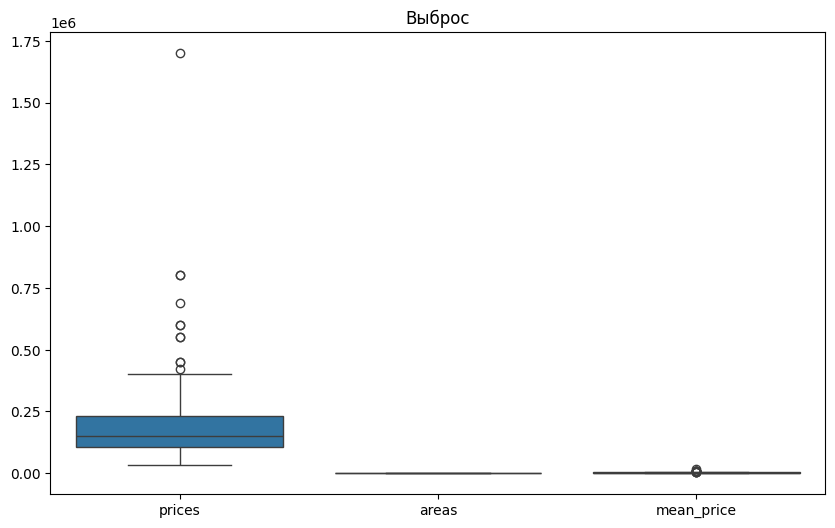

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data = df_places[['prices', 'areas', 'mean_price']])
plt.title('Выброс')
plt.show()

In [122]:
def remove_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  low_bound = Q1 - 1.5 * IQR
  upp_bound = Q3 + 1.5 * IQR

  mean_value = df[column].mean()

  df_filtered = df[(df[column] >= low_bound) & (df[column] <= upp_bound)]

  return df_filtered

In [123]:
for column in ['prices', 'areas', 'mean_price']:
    df_places = remove_outliers_iqr(df_places, column)

df_places

,prices,latitudes,longitudes,metro_stations,areas,floors,min_books,mean_price,metro,time,min_time
0,215000,55.556722,37.510812,"[(Потапово, 11–15), (Улица Горчаковаот, 31), (...",95.7,1.0,11 мес.,2246.6,"[Потапово, Улица Горчаковаот, Бунинская аллеяот]","[13.0, 31.0, 31.0]",13.0
1,250000,55.733609,37.591692,"[(Парк культурыдо, 5), (Фрунзенская, 11–15), (...",52.0,1.0,11 мес.,4807.7,"[Парк культурыдо, Фрунзенская, Октябрьская]","[5.0, 13.0, 18.0]",5.0
2,330000,55.723876,37.777149,"[(Окская, 6–10), (Плющево, 11–15), (Вешняки, 1...",100.0,1.0,11 мес.,3300.0,"[Окская, Плющево, Вешняки]","[8.0, 13.0, 18.0]",8.0
3,210000,55.789492,37.655787,"[(Красносельская, 16–20), (Рижская, 21–30), (М...",84.0,1.0,11 мес.,2500.0,"[Красносельская, Рижская, Митьково]","[18.0, 25.5, 25.5]",18.0
4,108800,55.745199,37.664743,"[(Марксистская, 6–10), (Таганская, 11–15), (Пл...",59.3,4.0,11 мес.,1834.7,"[Марксистская, Таганская, Площадь Ильича]","[8.0, 13.0, 13.0]",8.0
...,...,...,...,...,...,...,...,...,...,...,...
374,100000,55.703545,37.736375,"[(Текстильщики, 6–10), (Печатники, 21–30), (Ку...",65.0,2.0,11 мес.,1538.5,"[Текстильщики, Печатники, Кузьминки]","[8.0, 25.5, 25.5]",8.0
378,120000,55.681202,37.437233,"[(Очаково, 16–20), (Озёрнаяот, 31), (Мещерская...",80.0,1.0,6 мес.,1500.0,"[Очаково, Озёрнаяот, Мещерскаяот]","[18.0, 31.0, 31.0]",18.0
379,142000,55.931972,37.386579,"[(Молжаниново, 21–30), (Новоподрезковоот, 31)]",60.4,1.0,11 мес.,2351.0,"[Молжаниново, Новоподрезковоот]","[25.5, 31.0]",25.5
380,202000,55.582431,37.581424,"[(Лесопарковаядо, 5), (Аннино, 11–15), (Улица ...",77.9,1.0,11 мес.,2593.1,"[Лесопарковаядо, Аннино, Улица Старокачаловская]","[5.0, 13.0, 25.5]",5.0


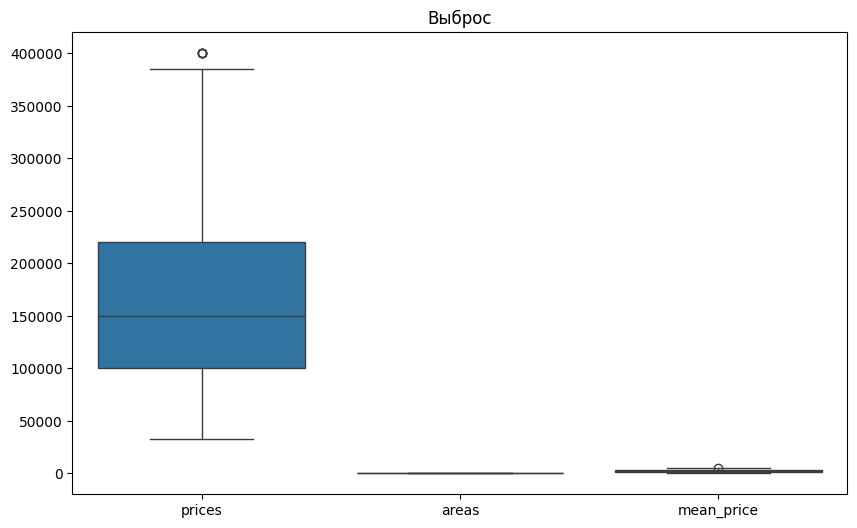

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data = df_places[['prices', 'areas', 'mean_price']])
plt.title('Выброс')
plt.show()

Так ок мы получили датафайл со всеми нужными значениями из одной таблицы, нарисуем карты пока просто по этим значениям, без добавления зп из второй таблицы.

In [132]:
import plotly.express as px
from numpy import nan

fig = px.scatter_mapbox(
    df_places.dropna(subset= ['min_time']).copy(),
    lat="latitudes",
    lon="longitudes",
    hover_data=['min_books'],
    size = 'min_time',
    color = 'mean_price',
    zoom=10,
    height=600,
    title="График стоимости за 1 кв.м. в Москве"
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})

<ipython-input-132-b70728a910f6>:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [133]:
df_vacancies

,wage,age,gender,metro,experience
0,40000.0,33.0,Женщина,NaN,157.0
1,30000.0,29.0,Женщина,Братиславская,127.0
2,30000.0,30.0,Мужчина,Парк Победы,150.0
3,NaN,57.0,Женщина,Отрадное,276.0
4,40000.0,29.0,Женщина,Новогиреево,113.0
...,...,...,...,...,...
157,30000.0,47.0,Женщина,NaN,114.0
158,40000.0,58.0,Женщина,Университет,188.0
159,25000.0,35.0,Мужчина,NaN,211.0
160,27000.0,45.0,Женщина,Выхино,275.0


То что я сейчас посчитаю, это чисто для меня. А вдруг корреляция хоть какая-то есть))))

In [134]:
df = df_vacancies.dropna(subset = ['wage']).copy()

In [135]:
df['wage'].corr(df['experience'])

np.float64(0.09921480624101353)

Ок, нет корреляции, начнем работать с этой таблицей. Нам необходимо объединить зп по станциям метро находя их среднее значение.

In [136]:
df_vacancies_metro = df_vacancies.dropna(subset=['metro', 'wage']).copy()

df_vacancies_metro = df_vacancies_metro.groupby('metro')['wage'].mean().reset_index()

df_vacancies_metro.rename(columns={'wage': 'mean_wage'}, inplace=True)

df_vacancies_metro

,metro,mean_wage
0,Автозаводская,50000.000000
1,Академическая,25000.000000
2,Алексеевская,40000.000000
3,Алтуфьево,45000.000000
4,Аннино,25000.000000
5,Бабушкинская,50000.000000
6,Бибирево,35000.000000
7,Борисово,40000.000000
8,Братиславская,32500.000000
9,Бульвар Адмирала Ушакова,35000.000000


In [137]:
df_places['mean_wage'] = np.nan

for index, row in df_places.iterrows():
    metro_names = row['metro']
    for metro_name in metro_names:
      matching_vac = df_vacancies_metro[df_vacancies_metro['metro'].str.contains(metro_name)]
      if not matching_vac.empty:
          df_places.at[index, 'mean_wage'] = matching_vac['mean_wage'].mean()

df_places['mean_cost'] = df_places['mean_price'] * 30 + df_places['mean_wage'].fillna(0)
df_places.loc[df_places['mean_wage'].isna(), 'mean_cost'] = np.nan

df_places

,prices,latitudes,longitudes,metro_stations,areas,floors,min_books,mean_price,metro,time,min_time,mean_wage,mean_cost
0,215000,55.556722,37.510812,"[(Потапово, 11–15), (Улица Горчаковаот, 31), (...",95.7,1.0,11 мес.,2246.6,"[Потапово, Улица Горчаковаот, Бунинская аллеяот]","[13.0, 31.0, 31.0]",13.0,NaN,NaN
1,250000,55.733609,37.591692,"[(Парк культурыдо, 5), (Фрунзенская, 11–15), (...",52.0,1.0,11 мес.,4807.7,"[Парк культурыдо, Фрунзенская, Октябрьская]","[5.0, 13.0, 18.0]",5.0,25000.000000,169231.000000
2,330000,55.723876,37.777149,"[(Окская, 6–10), (Плющево, 11–15), (Вешняки, 1...",100.0,1.0,11 мес.,3300.0,"[Окская, Плющево, Вешняки]","[8.0, 13.0, 18.0]",8.0,NaN,NaN
3,210000,55.789492,37.655787,"[(Красносельская, 16–20), (Рижская, 21–30), (М...",84.0,1.0,11 мес.,2500.0,"[Красносельская, Рижская, Митьково]","[18.0, 25.5, 25.5]",18.0,NaN,NaN
4,108800,55.745199,37.664743,"[(Марксистская, 6–10), (Таганская, 11–15), (Пл...",59.3,4.0,11 мес.,1834.7,"[Марксистская, Таганская, Площадь Ильича]","[8.0, 13.0, 13.0]",8.0,35000.000000,90041.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,100000,55.703545,37.736375,"[(Текстильщики, 6–10), (Печатники, 21–30), (Ку...",65.0,2.0,11 мес.,1538.5,"[Текстильщики, Печатники, Кузьминки]","[8.0, 25.5, 25.5]",8.0,28333.333333,74488.333333
378,120000,55.681202,37.437233,"[(Очаково, 16–20), (Озёрнаяот, 31), (Мещерская...",80.0,1.0,6 мес.,1500.0,"[Очаково, Озёрнаяот, Мещерскаяот]","[18.0, 31.0, 31.0]",18.0,NaN,NaN
379,142000,55.931972,37.386579,"[(Молжаниново, 21–30), (Новоподрезковоот, 31)]",60.4,1.0,11 мес.,2351.0,"[Молжаниново, Новоподрезковоот]","[25.5, 31.0]",25.5,NaN,NaN
380,202000,55.582431,37.581424,"[(Лесопарковаядо, 5), (Аннино, 11–15), (Улица ...",77.9,1.0,11 мес.,2593.1,"[Лесопарковаядо, Аннино, Улица Старокачаловская]","[5.0, 13.0, 25.5]",5.0,25000.000000,102793.000000


In [138]:
fig = px.scatter_mapbox(
    df_places.dropna(subset= ['mean_wage']).copy(),
    lat="latitudes",
    lon="longitudes",
    hover_data=['min_books'],
    size = 'min_time',
    color = 'mean_wage',
    zoom=10,
    height=600,
    title="График стоимости за 1 кв.м. в Москве"
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})

<ipython-input-138-7f1d5f8d0c6b>:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [139]:
fig = px.scatter_mapbox(
    df_places.dropna(subset= ['mean_wage']).copy(),
    lat="latitudes",
    lon="longitudes",
    hover_data=['min_books'],
    size = 'min_time',
    color = 'mean_cost',
    zoom=10,
    height=600,
    title="График стоимости за 1 кв.м. в Москве"
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})

<ipython-input-139-f864bbc2c628>:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

